# 第 3 关 · 结图者

kNN 图 + 边特征。今天**不加任何新的网络结构**，只把输入换成图。

要搞懂的是五问第 1 问：结构怎么变成模型输入，为什么只用距离不用坐标？

**BOSS：几何自测 8/8，且恢复率 ≥ 第 2 关 + 1.5 个百分点**

---

**这一关有 7 个部分：**

0. 准备
1. kNN 图：每个核苷酸看周围 16 个邻居
2. RBF：把一个距离摊成 16 个数
3. 边特征拼装
4. 亲手验证旋转不变性
5. 配对检测自检
6. 模型、训练、BOSS

## 部分 0 · 准备

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "minif").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("仓库根：", ROOT)

from minif.plotting import setup
plt = setup()

仓库根： /Users/bf/Documents/GitHub/rna-protein-inverse-folding


In [2]:
import numpy as np
import torch
import torch.nn as nn

from minif import data, engine, features as F, pairing, scoreboard
from minif.model import mlp
from minif.plotting import tidy, seq_cmap, PALETTE

MOL = "rna"
tr = data.load(MOL, "train"); va = data.load(MOL, "val")
data.describe(tr, "训练集："); data.describe(va, "验证集：")

训练集：295 条，长度 30-118（平均 68），总残基 20176，配对 6638 对
验证集：21 条，长度 30-70（平均 45），总残基 941，配对 298 对


## 部分 1 · kNN 图：每个核苷酸看周围 16 个邻居

按 C4' 之间的距离找最近的 16 个。注意输出 `idx` 的形状是 `[L, 16]`——
第 i 行是第 i 个核苷酸的 16 个邻居编号。

In [24]:
r = tr[0]
c4 = r["coords"][:, F.MOL[MOL]["center"]]
idx = F.knn_graph(c4, k=32)
print("idx", idx.shape)
print("第 20 号核苷酸的邻居：", np.sort(idx[20]))
print("它们在序列上离 20 多远：", np.sort(idx[20] - 20))
print()
print("注意有些邻居在序列上离得很远——那些就是茎区里配对的对家，")
print("或者三级结构里折叠到一起的部分。这正是图比序列强的地方。")

idx (82, 32)
第 20 号核苷酸的邻居： [ 7  8  9 10 11 12 13 14 16 17 18 19 21 22 23 32 33 37 38 39 40 44 45 46
 53 54 60 61 62 63 64 65]
它们在序列上离 20 多远： [-13 -12 -11 -10  -9  -8  -7  -6  -4  -3  -2  -1   1   2   3  12  13  17
  18  19  20  24  25  26  33  34  40  41  42  43  44  45]

注意有些邻居在序列上离得很远——那些就是茎区里配对的对家，
或者三级结构里折叠到一起的部分。这正是图比序列强的地方。


## 部分 2 · RBF：把一个距离摊成 16 个数

为什么不直接用距离：一个标量线性进网络，表达力太弱。
摊成一组「离 3Å 多近、离 5Å 多近 ...」，网络就能学非线性的距离依赖。

输入距离 (400,)  -> 输出 (400, 16)


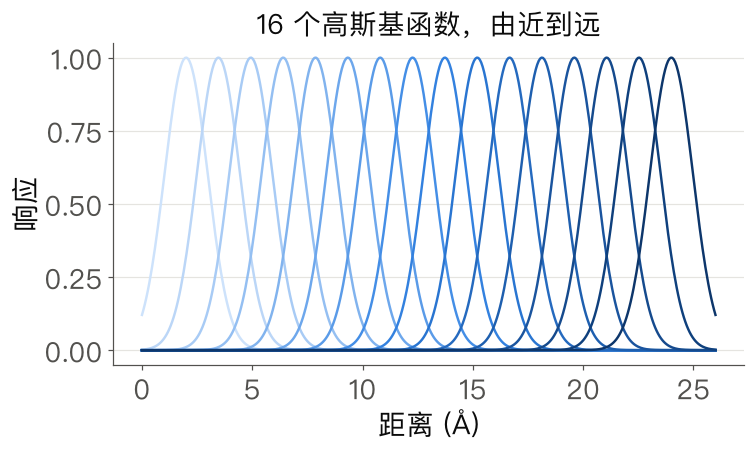

一个距离 d 进来，得到 16 个数——它落在哪几个基函数的范围内。


In [25]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "PingFang SC"
plt.rcParams["axes.unicode_minus"] = False
d = np.linspace(0, 26, 400)
resp = F.rbf(d, n_bins=16, d_min=2.0, d_max=24.0)
print("输入距离", d.shape, " -> 输出", resp.shape)

cmap = seq_cmap()
fig, ax = plt.subplots(figsize=(7.4, 3.8))
for i in range(resp.shape[1]):
    ax.plot(d, resp[:, i], color=cmap(i / (resp.shape[1] - 1)), lw=1.6)
ax.set_xlabel("距离 (Å)"); ax.set_ylabel("响应")
ax.set_title("16 个高斯基函数，由近到远")
tidy(ax); plt.show()
print("一个距离 d 进来，得到 16 个数——它落在哪几个基函数的范围内。")

## 部分 3 · 边特征拼装

i 和 j 各 4 个原子，两两 16 个距离，每个摊成 16 个 RBF = 256 维，
再拼上 33 维的「序列上隔多远」one-hot，一共 289 维。

**相对序列位置这一维在 RNA 上格外重要**：空间上挨着的两个碱基，
可能是序列邻居（i, i+1），也可能是茎区里隔了几十位的配对对家。含义完全不同。

In [26]:
E = F.edge_features(r["coords"], idx, r["resnum"], MOL)
print("边特征", E.shape, " = [L, k, %d]" % F.edge_dim(MOL))
print("  其中 16 个原子对 × 16 个 RBF =", 16*16)
print("  相对序列位置 one-hot        =", F.edge_dim(MOL) - 256)

边特征 (82, 32, 289)  = [L, k, 289]
  其中 16 个原子对 × 16 个 RBF = 256
  相对序列位置 one-hot        = 33


## 部分 4 · 亲手验证旋转不变性

**这是第 1 问的答案。** 把整条 RNA 随机转一下再平移，所有特征必须一模一样。
RNA 在空间里转一下还是同一条 RNA，模型输出就必须一样。
如果直接喂坐标 xyz，模型得自己从数据里学会这件事，纯属浪费容量。

In [27]:
rng = np.random.RandomState(0)
Q, _ = np.linalg.qr(rng.randn(3, 3))
if np.linalg.det(Q) < 0:
    Q[:, 0] *= -1
xyz2 = ((r["coords"].reshape(-1, 3) @ Q.T) + np.array([13., -7., 42.])
        ).reshape(r["coords"].shape).astype(np.float32)

print("转之前第 0 个 P 原子：", r["coords"][0, 0])
print("转之后第 0 个 P 原子：", xyz2[0, 0])
print("   坐标完全不同\n")

V1 = F.node_features(r["coords"], MOL, r["partner"], r.get("chi"))
V2 = F.node_features(xyz2, MOL, r["partner"])
E2 = F.edge_features(xyz2, idx, r["resnum"], MOL)
print("点特征最大差 %.2e" % np.abs(V1 - V2).max())
print("边特征最大差 %.2e" % np.abs(E - E2).max())
print("   特征一模一样  <- 这就是只用距离的理由")

转之前第 0 个 P 原子： [  7.179  12.388 -16.451]
转之后第 0 个 P 原子： [ 25.461748 -23.499111  35.06313 ]
   坐标完全不同

点特征最大差 2.00e+00
边特征最大差 4.77e-06
   特征一模一样  <- 这就是只用距离的理由


In [28]:
# 反过来：镜像翻转应该改变特征，否则模型分不清右手螺旋和左手螺旋
mir = r["coords"].copy(); mir[..., 0] *= -1
print("镜像后点特征最大差 %.3f  （应该明显不为 0）"
      % np.abs(V1 - F.node_features(mir, MOL, r["partner"], r.get("chi"))).max())

镜像后点特征最大差 1.999  （应该明显不为 0）


## 部分 5 · 配对检测自检

第 5 关要用配对有效率这个指标，它依赖配对检测。先确认检测器靠谱：
**检测出来的配对应该 90% 以上是 AU / GC / GU。**

In [29]:
comp = {}
for x in tr:
    for k, v in pairing.pair_composition(x["seq"], x["partner"]).items():
        comp[k] = comp.get(k, 0) + v
tot = sum(comp.values()); canon = sum(v for k, v in comp.items() if k != "其他")
print("共 %d 对，规范配对 %.1f%%" % (tot, 100*canon/max(tot, 1)))
for k, v in sorted(comp.items(), key=lambda kv: -kv[1]):
    print("  %-4s %5d  %5.1f%%" % (k, v, 100*v/tot))
print()
print("低于 90% 说明检测器有问题，第 5 关的指标会不可信——回来说一声。")

共 6638 对，规范配对 90.4%
  GC    2123   32.0%
  CG    1635   24.6%
  UA     926   13.9%
  AU     897   13.5%
  其他     636    9.6%
  GU     252    3.8%
  UG     169    2.5%

低于 90% 说明检测器有问题，第 5 关的指标会不可信——回来说一声。


## 部分 6 · 模型、训练、BOSS

点特征 + 邻居边特征的**简单平均**。没有可学习的消息传递，那是第 4 关的事。

In [30]:
class MeanPoolGraph(nn.Module):
    def __init__(self, d_node, d_edge, n_out, d=128):
        super().__init__()
        self.embed_E = nn.Linear(d_edge, d)
        self.head = mlp(d_node + d, d, n_out)

    def forward(self, V, E, idx):
        return self.head(torch.cat([V, self.embed_E(E).mean(dim=1)], dim=-1))

model = MeanPoolGraph(F.node_dim(MOL), F.edge_dim(MOL), F.n_letters(MOL))
print("参数量", sum(p.numel() for p in model.parameters()))

参数量 71940


In [31]:
best = engine.fit(model, tr, va, MOL, epochs=40, lr=1e-3,
                  autoregressive=False, log_every=5, level=3, eval_pairs=False)

  ep  1  训练 loss 1.314 恢复 36.8%   验证 loss 1.260 恢复 42.4%   最好 42.4%  [1s]
  ep  5  训练 loss 1.154 恢复 49.1%   验证 loss 1.171 恢复 50.1%   最好 50.1%  [4s]
  ep 10  训练 loss 1.063 恢复 55.1%   验证 loss 1.184 恢复 51.9%   最好 52.3%  [8s]
  ep 15  训练 loss 0.989 恢复 58.9%   验证 loss 1.165 恢复 51.2%   最好 52.3%  [12s]
  ep 20  训练 loss 0.918 恢复 62.6%   验证 loss 1.168 恢复 49.4%   最好 52.3%  [16s]
  ep 25  训练 loss 0.857 恢复 65.2%   验证 loss 1.289 恢复 48.9%   最好 52.6%  [19s]
  ep 30  训练 loss 0.793 恢复 68.5%   验证 loss 1.297 恢复 50.7%   最好 52.6%  [23s]
  ep 35  训练 loss 0.722 恢复 71.4%   验证 loss 1.376 恢复 49.9%   最好 52.6%  [27s]
  ep 40  训练 loss 0.657 恢复 74.2%   验证 loss 1.502 恢复 48.6%   最好 52.6%  [30s]

验证集最好恢复率：52.6%

[记分板] 第 3 关：geometry_tests=8  recovery=0.533
[记分板] 挑战 BOSS：python game.py check 3


In [32]:
!cd .. && python tests/test_geometry.py

1. 二面角 vs 参考实现，最大误差 4.3e-09
2. 蛋白 alpha 螺旋 phi=-57.0 psi=-47.0 |omega|=180.0 （期望 -57 / -47 / 180）
3. 蛋白 手性 +43.0（右手为正） CA(i,i+1)=3.80(~3.8) CA(i,i+4)=6.38(~6.2) CA-CB=1.53(~1.53)
4. RNA 规则螺旋 eta=149.3±0.00  theta=-133.4±0.00  chi=58.0±0.00 （标准差应≈0）
5. rna     旋转平移后 V 差 6.3e-06  E 差 3.2e-06  邻居集合一致 True
5. protein 旋转平移后 V 差 3.5e-06  E 差 4.6e-06  邻居集合一致 True
6. rna     镜像后 V 差 1.697（应明显不为 0）
6. protein 镜像后 V 差 1.677（应明显不为 0）
7. RNA V(20, 10) E(20, 8, 289)（边应 289 维）　蛋白 V(24, 9) E(24, 8, 433)（边应 433 维）　L=4,k=16 -> idx(4, 16)
8. 近邻偏移  RNA [-4 -3 -2 -1  1  2  3  4]   蛋白 [-4 -3 -2 -1  1  2  3  4] （都应左右对称）

全部通过  8/8

[记分板] 第 3 关：geometry_tests=8  recovery=0.533
[记分板] 挑战 BOSS：python game.py check 3


In [33]:
!cd .. && python game.py check 3


  ── 第 3 关 BOSS：结图者 ──
  要求：几何自测 8/8，且恢复率 ≥ 第 2 关 + 1.5 个百分点

  ✔ 恢复率 53.3% ≥ 上一关 51.2% + 1.5（现在超出 +2.1 个百分点）
  ✔ 几何自测 8/8

  通过。第 3 关已通关。



## 练习

1. 把部分 1 的 `k` 从 16 改成 4，再改成 32，各跑 10 轮。k 越大越好吗？
2. 把相对位置 one-hot 关掉（改 `features.py` 的 `edge_features`），掉多少？

### 自测三问

1. 结构输入为什么只用距离，不用坐标？
2. 相对序列位置这个特征在 RNA 上为什么格外重要？
3. A 型螺旋在 eta-theta 图上聚成一团，这说明什么？

写进 `notes/level3.md`。